# FIUBA - Maestría en Inteligencia Artificial
## Algoritmos Evolutivos 1 (2026)
### Desafío Práctico: Optimización de Ubicación de Antenas (PSO)

**Alumno:** Martín Andújar  
**Docente:** Esp. Ing. Miguel Augusto Azar  

En esta versión definitiva se implementan **coordenadas reales (latitud/longitud)** y la fórmula de **Haversine** para medir distancias sobre la superficie terrestre en km. Además, como bonus track estadístico, se comparan **3 variantes de PSO** mediante un diagrama de caja (boxplot).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DEL ESCENARIO (Coordenadas Reales)
np.random.seed(42)
N_CLIENTES = 30

# Límites geográficos aproximados de la zona
LAT_MIN, LAT_MAX = -34.9, -34.3
LON_MIN, LON_MAX = -58.9, -58.1

CLIENTES_LAT = np.random.uniform(LAT_MIN, LAT_MAX, N_CLIENTES)
CLIENTES_LON = np.random.uniform(LON_MIN, LON_MAX, N_CLIENTES)

N_ANTENAS = 3
RADIO_COBERTURA = 15.0 # Radio en km
DIMENSION = N_ANTENAS * 2

def haversine(lat1, lon1, lat2, lon2):
    # Función para calcular distancia real entre latitudes y longitudes
    R = 6371.0 # Radio de la Tierra en km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def evaluar_fitness(particula):
    pos_antenas = particula.reshape(N_ANTENAS, 2)
    clientes_cubiertos = 0
    for i in range(N_CLIENTES):
        clat, clon = CLIENTES_LAT[i], CLIENTES_LON[i]
        for j in range(N_ANTENAS):
            alat, alon = pos_antenas[j][0], pos_antenas[j][1]
            if haversine(clat, clon, alat, alon) <= RADIO_COBERTURA:
                clientes_cubiertos += 1
                break
    return -clientes_cubiertos

### 2. Ejecución y Comparativa de Variantes PSO
Se ejecutarán 30 iteraciones independientes para 3 variantes de PSO: **Estándar, Factor de Constricción e Inercia Decreciente** para armar los Boxplots solicitados.

In [2]:
N_PARTICULAS = 20
MAX_ITERACIONES = 50
EJECUCIONES_TOTALES = 30

# Diccionario con las variantes a comparar
variantes = {
    "Estándar": {"w": 0.5, "c1": 1.5, "c2": 1.5},
    "Constricción": {"w": 0.729, "c1": 1.49445, "c2": 1.49445},
    "Inercia Decreciente": {"w_max": 0.9, "w_min": 0.4, "c1": 1.8, "c2": 1.8}
}

resultados_fitness = {k: [] for k in variantes.keys()}
mejor_historial_conv = []
mejor_pos_global = None
mejor_fitness_absoluto = float('inf')
mejor_nombre_variante = ""

for nombre, params in variantes.items():
    for ejecucion in range(EJECUCIONES_TOTALES):
        posiciones = np.zeros((N_PARTICULAS, DIMENSION))
        # Inicializar respetando los límites de latitud y longitud
        for i in range(N_PARTICULAS):
            for j in range(N_ANTENAS):
                posiciones[i, j*2] = np.random.uniform(LAT_MIN, LAT_MAX)
                posiciones[i, j*2+1] = np.random.uniform(LON_MIN, LON_MAX)

        velocidades = np.random.uniform(-0.05, 0.05, (N_PARTICULAS, DIMENSION))
        p_best_pos = np.copy(posiciones)
        p_best_fitness = np.array([evaluar_fitness(p) for p in posiciones])

        g_best_idx = np.argmin(p_best_fitness)
        g_best_pos = np.copy(p_best_pos[g_best_idx])
        g_best_fitness = p_best_fitness[g_best_idx]

        convergencia_local = [abs(g_best_fitness)]

        for iteracion in range(MAX_ITERACIONES):
            if nombre == "Inercia Decreciente":
                w = params["w_max"] - ((params["w_max"] - params["w_min"]) * (iteracion / MAX_ITERACIONES))
            else:
                w = params["w"]
            c1, c2 = params["c1"], params["c2"]

            for i in range(N_PARTICULAS):
                r1, r2 = np.random.rand(DIMENSION), np.random.rand(DIMENSION)
                velocidades[i] = (w * velocidades[i] +
                                  c1 * r1 * (p_best_pos[i] - posiciones[i]) +
                                  c2 * r2 * (g_best_pos - posiciones[i]))
                posiciones[i] += velocidades[i]

                # Confinamiento en los límites del mapa
                for j in range(N_ANTENAS):
                    posiciones[i, j*2] = np.clip(posiciones[i, j*2], LAT_MIN, LAT_MAX)
                    posiciones[i, j*2+1] = np.clip(posiciones[i, j*2+1], LON_MIN, LON_MAX)

                fit = evaluar_fitness(posiciones[i])
                if fit < p_best_fitness[i]:
                    p_best_fitness[i] = fit
                    p_best_pos[i] = np.copy(posiciones[i])
                    if fit < g_best_fitness:
                        g_best_fitness = fit
                        g_best_pos = np.copy(posiciones[i])

            convergencia_local.append(abs(g_best_fitness))

        resultados_fitness[nombre].append(abs(g_best_fitness))
        if g_best_fitness < mejor_fitness_absoluto:
            mejor_fitness_absoluto = g_best_fitness
            mejor_pos_global = np.copy(g_best_pos)
            mejor_historial_conv = convergencia_local
            mejor_nombre_variante = nombre

print(f"Pruebas completadas.")
print(f"El mejor rendimiento absoluto fue de {abs(mejor_fitness_absoluto)} clientes conectados usando la variante: {mejor_nombre_variante}")

Pruebas completadas.
El mejor rendimiento absoluto fue de 21 clientes conectados usando la variante: Estándar


### 3. Visualización de la Variante Óptima y Diagramas de Caja

/tmp/ipykernel_2950/211598575.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, patch_artist=True, boxprops=dict(facecolor='lightblue'), labels=etiquetas)


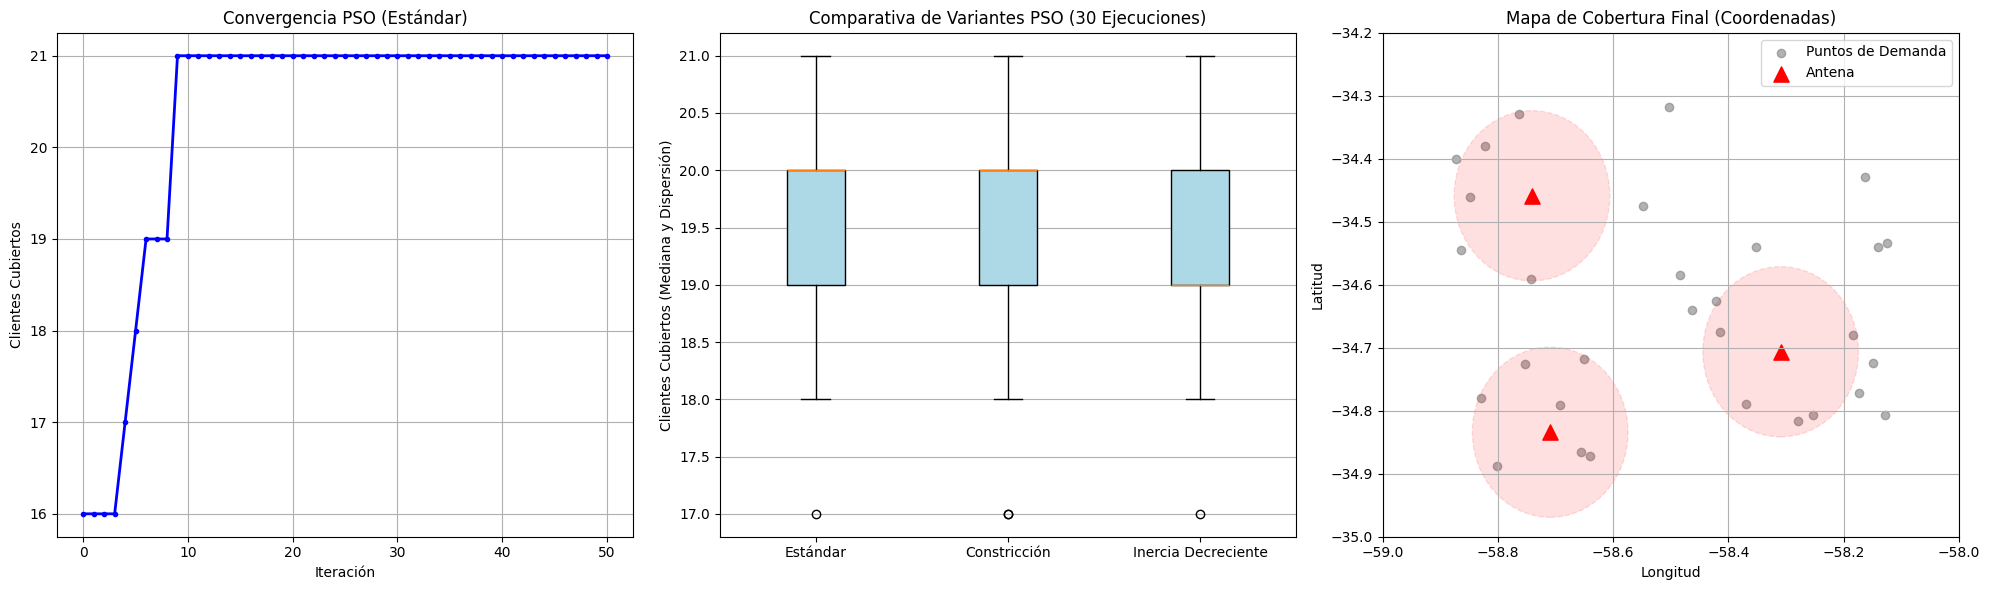

In [3]:
plt.figure(figsize=(20, 6))

# Gráfico 1: Curva de Convergencia (Obligatorio)
plt.subplot(1, 3, 1)
plt.plot(mejor_historial_conv, color='blue', linewidth=2, marker='o', markersize=3)
plt.title(f'Convergencia PSO ({mejor_nombre_variante})')
plt.xlabel('Iteración')
plt.ylabel('Clientes Cubiertos')
plt.grid(True)

# Gráfico 2: Diagrama de Caja (Boxplot) de Comparación
plt.subplot(1, 3, 2)
etiquetas = list(resultados_fitness.keys())
datos = [resultados_fitness[k] for k in etiquetas]
plt.boxplot(datos, patch_artist=True, boxprops=dict(facecolor='lightblue'), labels=etiquetas)
plt.title('Comparativa de Variantes PSO (30 Ejecuciones)')
plt.ylabel('Clientes Cubiertos (Mediana y Dispersión)')
plt.grid(axis='y')

# Gráfico 3: Mapa de Coordenadas Reales Final
plt.subplot(1, 3, 3)
plt.scatter(CLIENTES_LON, CLIENTES_LAT, color='gray', label='Puntos de Demanda', alpha=0.6)
antenas_optimas = mejor_pos_global.reshape(N_ANTENAS, 2)
for idx, antena in enumerate(antenas_optimas):
    plt.scatter(antena[1], antena[0], color='red', marker='^', s=120, label='Antena' if idx==0 else "")
    # Nota: El círculo se visualiza ligeramente deformado según las dimensiones del plot
    # porque los grados de lat/lon no son cuadrados métricos perfectos.
    circulo = plt.Circle((antena[1], antena[0]), RADIO_COBERTURA/111.0, color='red', fill=True, alpha=0.12, linestyle='--')
    plt.gca().add_patch(circulo)
plt.title('Mapa de Cobertura Final (Coordenadas)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.xlim(LON_MIN - 0.1, LON_MAX + 0.1)
plt.ylim(LAT_MIN - 0.1, LAT_MAX + 0.1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()